In [1]:
import faiss

In [5]:
import timeit
from collections import defaultdict

from faiss.contrib.datasets import SyntheticDataset

ds: SyntheticDataset = SyntheticDataset(256, 10_000, 10_000, 100)
nlist: int = 1000
turboquant_bits = [1, 2, 3, 4, 8]

# TurboQuant is designed for unit-normalized vectors, so normalize the
# synthetic train / database / query splits before building indexes.
for vectors in (ds.get_train(), ds.get_database(), ds.get_queries()):
    faiss.normalize_L2(vectors)

# This will contain <"index name", ([recalls], [speeds], [labels (the k)])>
recall_speed_data = defaultdict(lambda: [[], [], []])
# This will contain <"index name", ([recalls], [memory for this index])>
recall_memory_data = defaultdict(lambda: [[], []])

In [6]:
# Helpers
def trials(index, xq, k):
    trials = 10
    result = timeit.timeit(
        stmt="index.search(xq, k)",
        number=trials,
        globals={"index": index, "xq": xq, "k": k},
    )
    return result / trials * 1000.0  # ms


def trials_ivf(index, xq, k, params=None):
    trials = 10
    result = timeit.timeit(
        stmt="search_with_parameters(index, xq, k, params)",
        number=trials,
        globals={
            "search_with_parameters": faiss.search_with_parameters,
            "index": index,
            "xq": xq,
            "k": k,
            "params": params,
        },
    )
    return result / trials * 1000.0  # ms


def compute_recall(ground_truth_I, predicted_I):
    n_queries, k = ground_truth_I.shape
    intersection = faiss.eval_intersection(ground_truth_I, predicted_I)
    recall = intersection / (n_queries * k)
    return recall


def create_index(ds, factory_string):
    index = faiss.index_factory(ds.d, factory_string)
    index.train(ds.get_train())
    index.add(ds.get_database())
    return index


def code_memory(index):
    code_size = getattr(index, "code_size", None)
    if code_size is None:
        code_size = index.sa_code_size()
    return code_size * index.ntotal


# pyre-ignore
def handle_index(prefix, index, ds, mem, k):
    gt_I = ds.get_groundtruth(k)
    _, I_res = index.search(ds.get_queries(), k)
    avg_speed = trials(index, ds.get_queries(), k)
    recall = compute_recall(gt_I, I_res)
    print(
        f"{prefix} recall@{k}: {recall}.  Average speed: {avg_speed:.1f}ms.  Memory: {mem/1e6:.3f}MB"
    )
    recall_speed_data[prefix][0].append(recall)
    recall_speed_data[prefix][1].append(avg_speed)
    recall_speed_data[prefix][2].append(f"k={k}")
    recall_memory_data[prefix][0].append(recall)
    recall_memory_data[prefix][1].append(mem)


# pyre-ignore
def handle_ivf_index(prefix, index, ds, mem, k, params):
    gt_I = ds.get_groundtruth(k)
    for nprobe in 4, 16, 32:
        params.nprobe = nprobe
        _, I_res = faiss.search_with_parameters(index, ds.get_queries(), k, params)
        avg_speed = trials_ivf(index, ds.get_queries(), k, params)
        recall = compute_recall(gt_I, I_res)
        print(
            f"{prefix} nprobe={nprobe}: recall@{k}: {recall}.  Average speed: {avg_speed:.1f}ms.  Memory: {mem/1e6:.3f}MB"
        )
        recall_speed_data[prefix][0].append(recall)
        recall_speed_data[prefix][1].append(avg_speed)
        recall_speed_data[prefix][2].append(f"k={k}, nprobe={nprobe}")
        recall_memory_data[prefix][0].append(recall)
        recall_memory_data[prefix][1].append(mem)


# pyre-ignore
def vary_k_nprobe_measuring_recall_and_memory(prefix, index, ds, mem):
    classname = type(index).__name__
    for k in 1, 10, 100:
        if classname in [
            "IndexScalarQuantizer",
            "IndexPQFastScan",
            "IndexHNSWFlat",
        ]:
            handle_index(prefix, index, ds, mem, k)
        elif classname in [
            "IndexIVFPQFastScan",
            "IndexIVFScalarQuantizer",
        ]:
            params = faiss.IVFSearchParameters()
            handle_ivf_index(prefix, index, ds, mem, k, params)
        else:
            raise RuntimeError(f"Unsupported index type for benchmark: {classname}")


In [15]:
# TurboQuant SQ
for bits in turboquant_bits:
    fac_s = f"SQtqmse{bits}"
    print(fac_s)
    tq = create_index(ds, fac_s)
    mem = code_memory(tq)
    vary_k_nprobe_measuring_recall_and_memory(fac_s, tq, ds, mem)
    del tq

# IVF TurboQuant SQ
for bits in turboquant_bits:
    fac_s = f"IVF{nlist},SQtqmse{bits}"
    tq = create_index(ds, fac_s)
    mem = code_memory(tq)
    vary_k_nprobe_measuring_recall_and_memory(fac_s, tq, ds, mem)
    del tq

# Scalar Quantizer
for bits in [4, 6, 8]:
    fac_s = f"SQ{bits}"
    sq = create_index(ds, fac_s)
    mem = code_memory(sq)
    vary_k_nprobe_measuring_recall_and_memory(f"Index{fac_s}", sq, ds, mem)
    del sq

# IVF Scalar Quantizer
for bits in [4, 6]:  # 8 seems to have no recall improvement in this dataset.
    fac_s = f"IVF{nlist},SQ{bits}"
    sq = create_index(ds, fac_s)
    mem = code_memory(sq)
    vary_k_nprobe_measuring_recall_and_memory(fac_s, sq, ds, mem)
    del sq

# PQFS
for m in [32, 64, 128]:
    fac_s = f"PQ{m}x4fs"
    pqfs = create_index(ds, fac_s)
    mem = code_memory(pqfs)
    vary_k_nprobe_measuring_recall_and_memory(fac_s, pqfs, ds, mem)
    del pqfs

# IVFPQFS
for m in [32, 64, 128]:
    fac_s = f"IVF{nlist},PQ{m}x4fs"
    ivf_pqfs = create_index(ds, fac_s)
    mem = code_memory(ivf_pqfs)
    vary_k_nprobe_measuring_recall_and_memory(fac_s, ivf_pqfs, ds, mem)
    del ivf_pqfs

# HNSW
for m in [8, 16, 32]:
    fac_s = f"HNSW{m}"
    index = create_index(ds, fac_s)
    storage = faiss.downcast_index(index.storage)
    mem = (
        storage.ntotal * storage.code_size
        + index.hnsw.neighbors.size() * 4
        + index.hnsw.offsets.size() * 8
    )
    vary_k_nprobe_measuring_recall_and_memory(fac_s, index, ds, mem)
    del index


SQtqmse1
SQtqmse1 recall@1: 0.79.  Average speed: 192.4ms.  Memory: 0.320MB
SQtqmse1 recall@10: 0.758.  Average speed: 224.8ms.  Memory: 0.320MB
SQtqmse1 recall@100: 0.737.  Average speed: 208.0ms.  Memory: 0.320MB
SQtqmse2
SQtqmse2 recall@1: 0.84.  Average speed: 204.6ms.  Memory: 0.640MB
SQtqmse2 recall@10: 0.827.  Average speed: 207.2ms.  Memory: 0.640MB
SQtqmse2 recall@100: 0.8147.  Average speed: 220.0ms.  Memory: 0.640MB
SQtqmse3
SQtqmse3 recall@1: 0.87.  Average speed: 217.8ms.  Memory: 0.960MB
SQtqmse3 recall@10: 0.89.  Average speed: 221.0ms.  Memory: 0.960MB
SQtqmse3 recall@100: 0.8717.  Average speed: 241.2ms.  Memory: 0.960MB
SQtqmse4
SQtqmse4 recall@1: 0.93.  Average speed: 231.3ms.  Memory: 1.280MB
SQtqmse4 recall@10: 0.876.  Average speed: 236.0ms.  Memory: 1.280MB
SQtqmse4 recall@100: 0.8449.  Average speed: 225.8ms.  Memory: 1.280MB
SQtqmse8
SQtqmse8 recall@1: 1.0.  Average speed: 216.9ms.  Memory: 2.560MB
SQtqmse8 recall@10: 0.991.  Average speed: 232.4ms.  Memory: 2.

WARNING clustering 10000 points to 1000 centroids: please provide at least 39000 training points


IVF1000,SQtqmse1 nprobe=4: recall@1: 0.52.  Average speed: 18.1ms.  Memory: 0.320MB
IVF1000,SQtqmse1 nprobe=16: recall@1: 0.65.  Average speed: 48.3ms.  Memory: 0.320MB
IVF1000,SQtqmse1 nprobe=32: recall@1: 0.67.  Average speed: 88.2ms.  Memory: 0.320MB
IVF1000,SQtqmse1 nprobe=4: recall@10: 0.422.  Average speed: 17.3ms.  Memory: 0.320MB
IVF1000,SQtqmse1 nprobe=16: recall@10: 0.6.  Average speed: 49.9ms.  Memory: 0.320MB
IVF1000,SQtqmse1 nprobe=32: recall@10: 0.642.  Average speed: 89.7ms.  Memory: 0.320MB
IVF1000,SQtqmse1 nprobe=4: recall@100: 0.2211.  Average speed: 18.9ms.  Memory: 0.320MB
IVF1000,SQtqmse1 nprobe=16: recall@100: 0.4418.  Average speed: 51.2ms.  Memory: 0.320MB
IVF1000,SQtqmse1 nprobe=32: recall@100: 0.5239.  Average speed: 91.5ms.  Memory: 0.320MB


WARNING clustering 10000 points to 1000 centroids: please provide at least 39000 training points


IVF1000,SQtqmse2 nprobe=4: recall@1: 0.56.  Average speed: 17.5ms.  Memory: 0.640MB
IVF1000,SQtqmse2 nprobe=16: recall@1: 0.7.  Average speed: 48.5ms.  Memory: 0.640MB
IVF1000,SQtqmse2 nprobe=32: recall@1: 0.74.  Average speed: 90.8ms.  Memory: 0.640MB
IVF1000,SQtqmse2 nprobe=4: recall@10: 0.463.  Average speed: 18.0ms.  Memory: 0.640MB
IVF1000,SQtqmse2 nprobe=16: recall@10: 0.722.  Average speed: 50.4ms.  Memory: 0.640MB
IVF1000,SQtqmse2 nprobe=32: recall@10: 0.776.  Average speed: 90.2ms.  Memory: 0.640MB
IVF1000,SQtqmse2 nprobe=4: recall@100: 0.2215.  Average speed: 18.4ms.  Memory: 0.640MB
IVF1000,SQtqmse2 nprobe=16: recall@100: 0.5072.  Average speed: 51.8ms.  Memory: 0.640MB
IVF1000,SQtqmse2 nprobe=32: recall@100: 0.6594.  Average speed: 92.0ms.  Memory: 0.640MB


...

IVF1000,PQ32x4fs nprobe=4: recall@1: 0.39.  Average speed: 7.4ms.  Memory: 0.160MB
IVF1000,PQ32x4fs nprobe=16: recall@1: 0.47.  Average speed: 7.1ms.  Memory: 0.160MB
IVF1000,PQ32x4fs nprobe=32: recall@1: 0.46.  Average speed: 10.7ms.  Memory: 0.160MB
IVF1000,PQ32x4fs nprobe=4: recall@10: 0.404.  Average speed: 6.1ms.  Memory: 0.160MB
IVF1000,PQ32x4fs nprobe=16: recall@10: 0.514.  Average speed: 8.6ms.  Memory: 0.160MB
IVF1000,PQ32x4fs nprobe=32: recall@10: 0.529.  Average speed: 7.8ms.  Memory: 0.160MB
IVF1000,PQ32x4fs nprobe=4: recall@100: 0.2215.  Average speed: 6.3ms.  Memory: 0.160MB
IVF1000,PQ32x4fs nprobe=16: recall@100: 0.4464.  Average speed: 10.4ms.  Memory: 0.160MB
IVF1000,PQ32x4fs nprobe=32: recall@100: 0.5054.  Average speed: 8.1ms.  Memory: 0.160MB


WARNING clustering 10000 points to 1000 centroids: please provide at least 39000 training points


IVF1000,PQ64x4fs nprobe=4: recall@1: 0.58.  Average speed: 8.2ms.  Memory: 0.320MB
IVF1000,PQ64x4fs nprobe=16: recall@1: 0.7.  Average speed: 8.5ms.  Memory: 0.320MB
IVF1000,PQ64x4fs nprobe=32: recall@1: 0.74.  Average speed: 11.1ms.  Memory: 0.320MB
IVF1000,PQ64x4fs nprobe=4: recall@10: 0.455.  Average speed: 8.3ms.  Memory: 0.320MB
IVF1000,PQ64x4fs nprobe=16: recall@10: 0.683.  Average speed: 7.3ms.  Memory: 0.320MB
IVF1000,PQ64x4fs nprobe=32: recall@10: 0.726.  Average speed: 10.6ms.  Memory: 0.320MB
IVF1000,PQ64x4fs nprobe=4: recall@100: 0.2215.  Average speed: 8.2ms.  Memory: 0.320MB
IVF1000,PQ64x4fs nprobe=16: recall@100: 0.5001.  Average speed: 12.0ms.  Memory: 0.320MB
IVF1000,PQ64x4fs nprobe=32: recall@100: 0.6303.  Average speed: 9.8ms.  Memory: 0.320MB


WARNING clustering 10000 points to 1000 centroids: please provide at least 39000 training points


IVF1000,PQ128x4fs nprobe=4: recall@1: 0.6.  Average speed: 6.5ms.  Memory: 0.640MB
IVF1000,PQ128x4fs nprobe=16: recall@1: 0.77.  Average speed: 10.9ms.  Memory: 0.640MB
IVF1000,PQ128x4fs nprobe=32: recall@1: 0.81.  Average speed: 14.3ms.  Memory: 0.640MB
IVF1000,PQ128x4fs nprobe=4: recall@10: 0.468.  Average speed: 8.2ms.  Memory: 0.640MB
IVF1000,PQ128x4fs nprobe=16: recall@10: 0.753.  Average speed: 11.3ms.  Memory: 0.640MB
IVF1000,PQ128x4fs nprobe=32: recall@10: 0.822.  Average speed: 13.8ms.  Memory: 0.640MB
IVF1000,PQ128x4fs nprobe=4: recall@100: 0.2215.  Average speed: 7.5ms.  Memory: 0.640MB
IVF1000,PQ128x4fs nprobe=16: recall@100: 0.5105.  Average speed: 12.2ms.  Memory: 0.640MB
IVF1000,PQ128x4fs nprobe=32: recall@100: 0.6777.  Average speed: 15.2ms.  Memory: 0.640MB
HNSW8 recall@1: 0.89.  Average speed: 1.1ms.  Memory: 11.005MB
HNSW8 recall@10: 0.867.  Average speed: 1.2ms.  Memory: 11.005MB
HNSW8 recall@100: 0.5626.  Average speed: 1.6ms.  Memory: 11.005MB
HNSW16 recall@1: 0.9

In [13]:
%pip install matplotlib adjustText


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


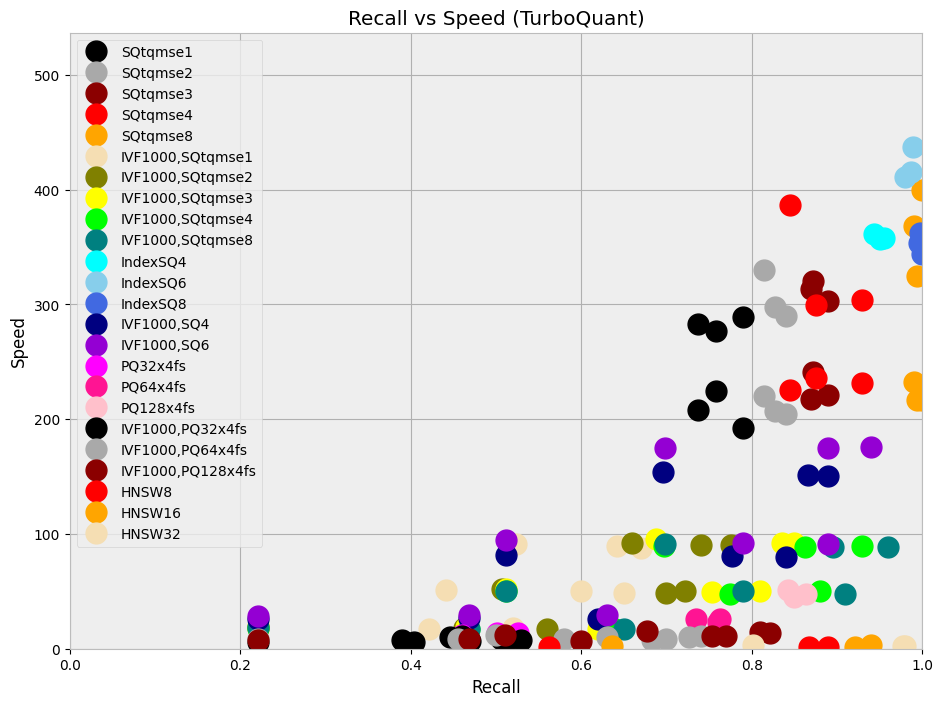

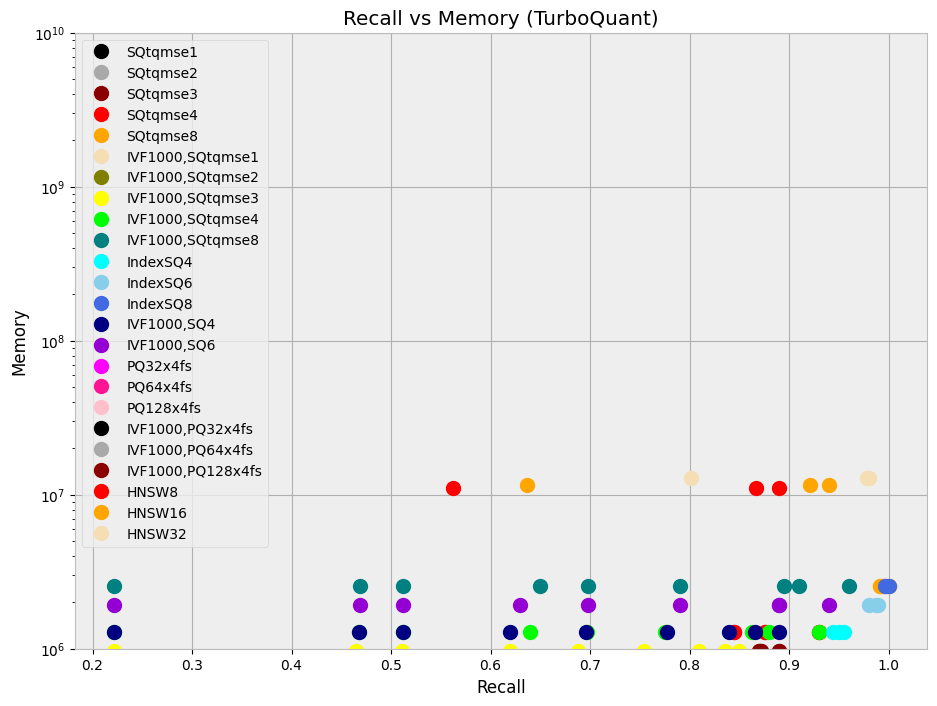

In [16]:
import matplotlib.pyplot as plt
from adjustText import adjust_text


# Specific colors that stand out against each other for this many data points.
colors = [
    "black",
    "darkgray",
    "darkred",
    "red",
    "orange",
    "wheat",
    "olive",
    "yellow",
    "lime",
    "teal",
    "cyan",
    "skyblue",
    "royalblue",
    "navy",
    "darkviolet",
    "fuchsia",
    "deeppink",
    "pink",
]

""":py"""
slowest_speed = 0.0
for key, vals in recall_speed_data.items():
    for speed in vals[1]:
        slowest_speed = max(slowest_speed, speed)

plt.axis([0, 1.0, 0, slowest_speed + 100.0])  # [xmin, xmax, ymin, ymax]
for i, (key, vals) in enumerate(recall_speed_data.items()):
    recalls = vals[0]
    speeds = vals[1]
    plt.plot(
        recalls,
        speeds,
        linestyle=" ",
        marker="o",
        color=colors[i % len(colors)],
        label=key,
        markersize=15,
    )
    # Adding k and nprobe labels makes the diagram very busy, but can be enabled
    # by uncommenting the following lines:
    # ks = vals[2]
    # texts = []
    # for i, (x_val, y_val) in enumerate(zip(recalls, speeds)):
    #     texts.append(plt.text(x_val, y_val, ks[i]))
    # adjust_text(
    #     texts,
    #     arrowprops=dict(arrowstyle="-", color="black", lw=0.5),
    #     force_text=(0.1, 0.25),
    #     force_points=(0.2, 0.5),
    #     only_move={"points": "xy"},
    # )

plt.title("Recall vs Speed (TurboQuant)")
plt.xlabel("Recall")
plt.ylabel("Speed")
plt.legend()
plt.show()

""":py"""
plt.ylim(1e6, 1e10)
plt.yscale("log", base=10)

for i, (key, vals) in enumerate(recall_memory_data.items()):
    recalls = vals[0]
    mems = vals[1]
    plt.plot(
        recalls,
        mems,
        linestyle=" ",
        marker="o",
        color=colors[i % len(colors)],
        label=key,
        markersize=10,
    )

    texts = []
    adjust_text(
        texts,
        arrowprops=dict(arrowstyle="-", color="black", lw=0.5),
        force_text=(0.5, 0.25),
        force_points=(1.0, 1.5),
        expand_points=(5.0, 10.0),
    )

plt.title("Recall vs Memory (TurboQuant)")
plt.xlabel("Recall")
plt.ylabel("Memory")
plt.legend()
plt.show()